# Data Acquaintance
A ver Mariano, ahora resulta que este proyecto es tu tesis.  
Lo que pasa es que estoy viendo todos los datos y lo que hice y no me acuerdo de absolutamente nada, así que voy a tener que volver a analizar todo y entender bien de dónde vienen los resultados obtenidos. 

In [1]:
import os
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import LineString, MultiLineString, Polygon
import warnings

warnings.filterwarnings("ignore")
PATH_DATA = '../thesis-data'
# Load unprocessed data
READ_RAW_DATA = False

### Leemos los datos

- Los datos de las **cámaras** se pueden encontrar en: `https://datos.cdmx.gob.mx/dataset/fotocivicas`
- Los datos de los **incidentes viales** se pueden encontrar en: `https://datos.cdmx.gob.mx/dataset/incidentes-viales-c5`
- Los datos de los **ejes viales** se pueden encontrar en: `https://datos.cdmx.gob.mx/dataset/vialidades-de-la-ciudad-de-mexico`

In [2]:
# Datos de las ubicaciones de las cámaras de velocidad
# No se necesita hacer ningún tipo de transformación.
speed_cameras = gpd.read_file(
    os.path.join(
        PATH_DATA,
        'fotocivicas-ubicacion-puntos',
        'fotocivicas-ubicacion-puntos.shp'
    )
)

# Nota para el Mariano del futuro.
# No sé exactamente qué sea esto de speed camera lines
# pero creo que es el área de efectividad de estas, aunque
# no está especificado para todas las cámaras, solo algunas
speed_cameras_lines = gpd.read_file(
    os.path.join(
        PATH_DATA, 
        'fotocivicas-ubicacion-lineas',
        'fotocivicas-ubicacion-lineas.shp'
    )
)

In [32]:
# Datos de los incidentes viales
# Se necesita convertir a parquet porque los datos están pesadísimos en CSV

# También vamos a filtrar solo aquellos datos que sean de tipo A, es decir, Afirmativos
# Según la definición del C5, un incidente de tipo afirmativo es aquel en el cual una
# unidad de atención a emergencias fue despachada, 
# llegó al lugar de los hechos y confirmó la emergencia reportada

# En total, con los datos extraídos el día 30 de marzo del 2025,
# - Había un total de 2_115_080 incidentes en total 
# - Con fechas que iban desde el 31/dic/2013 hasta el 29/feb/2024

# Una vez que nos quedamos con los incidentes de tipo Afirmativos
# - Tenemos en total 866_230 incidentes reales
# - Con fechas en el mismo intervalo de tiempo
READ_RAW_DATA= True
if READ_RAW_DATA:
    accidentes = (
        pd
        .read_csv(
            os.path.join(
                PATH_DATA, 
                'raw-data', 
                'inViales_completa.csv'
            )
        )
        .query('codigo_cierre == "A"')
        .query('clas_con_f_alarma not in ("FALSA ALARMA", "INCIDENTES EXTERNOS")')
        .assign(
            timestamp_str=lambda x: x.fecha_creacion + " " + x.hora_creacion,
            timestamp=lambda x: pd.to_datetime(x.timestamp_str, format="%Y-%m-%d %H:%M:%S")
        )
        .astype({
            'tipo_incidente_c4':'category',
            'incidente_c4':'category',
            'clas_con_f_alarma':'category',
        })
        # [[
        #     'folio', 'timestamp', 'tipo_incidente_c4', 
        #     'incidente_c4', 'clas_con_f_alarma', 'latitud', 'longitud'
        # ]]
        .reset_index(drop=True)
        .pipe(
            lambda df: 
            gpd
            .GeoDataFrame(
                data=df.drop(['latitud', 'longitud'], axis=1),
                geometry=gpd.points_from_xy(df.longitud, df.latitud)
            )
        )
    )
else:
    accidentes = (
        pd
        .read_parquet(os.path.join(PATH_DATA, 'incidentes-viales.parquet'))
        .reset_index(drop=True)
        .pipe(
            lambda df: 
            gpd
            .GeoDataFrame(
                data=df.drop(['latitud', 'longitud'], axis=1),
                geometry=gpd.points_from_xy(df.longitud, df.latitud)
            )
        )
    )

In [4]:
# Datos de las vialidades principales
# Este es el único al que no hay que hacerle nada
# Solo considerar que el único que funciona es el GeoJson
# Porque el otro está en otras coordenadas
vialidades = gpd.read_file(os.path.join(PATH_DATA, 'vialidades.json'))

In [5]:
radares = gpd.read_file('../thesis-data/radares_fotocivicas.gpkg')

In [33]:
# La literatura separa los accidentes en dos tipos principales:
# PICs: personal injuries 
# FCSs: fatal crashes something
accidentes[['clas_con_f_alarma', 'incidente_c4', 'tipo_incidente_c4']].value_counts().sort_index()

clas_con_f_alarma  incidente_c4                      tipo_incidente_c4  
DELITO             Accidente automovilístico         Detención ciudadana        62
                   Atropellado                       Detención ciudadana       237
EMERGENCIA         Accidente automovilístico         Cadáver                  1882
                   Atropellado                       Cadáver                  2043
                   Choque con lesionados             Sismo                     164
                   Choque con prensados              Sismo                       1
                   Choque sin lesionados             Accidente              449837
                                                     Sismo                     203
                   Ferroviario                       Accidente                  51
                   Incidente de tránsito             Mi Calle                   13
                                                     Mi Taxi                     1
              

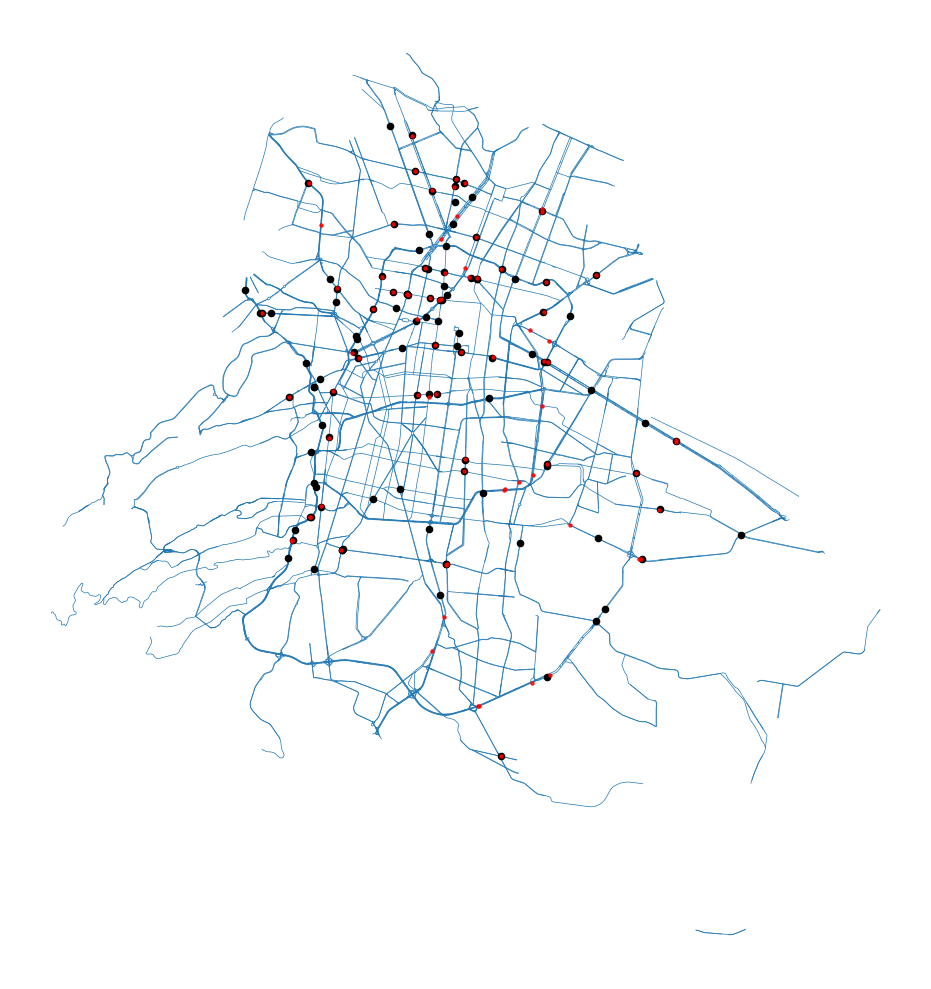

In [22]:
fig, ax = plt.subplots(figsize=(10,10))
ax.axis('off')
speed_cameras.plot(ax=ax, color='black', markersize=20)
radares.dropna(subset=['x']).query('anio == 2024 and tipo == "radar fijo"').plot(ax=ax, markersize=5, alpha=.8, color='red')
vialidades.plot(ax=ax, linewidth=.5, zorder=-1)
fig.tight_layout()